In [1]:
# ============================================================
# CELL 1 — CHECK COLAB ENVIRONMENT
# ============================================================

import sys
import tensorflow as tf

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

print("\nGPU:")
print(tf.config.list_physical_devices("GPU"))

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
TensorFlow: 2.20.0

GPU:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# CELL 2 — GPU INFORMATION
# ============================================================

!nvidia-smi

Tue Sep  1 08:36:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================================
# CELL 3 — CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# CELL 4 — PROJECT ORGANIZATION
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/CXR_Foundation_Workshop"

DIRECTORIES = [
    "dataset",
    "dataset/raw",
    "dataset/processed",
    "models",
    "embeddings",
    "results",
    "plots",
    "logs"
]

for directory in DIRECTORIES:
    path = os.path.join(PROJECT_DIR, directory)
    os.makedirs(path, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nProject structure created successfully.")

Project directory:
/content/drive/MyDrive/CXR_Foundation_Workshop

Project structure created successfully.


In [5]:
# ============================================================
# CELL 5 — CHECK PROJECT STRUCTURE
# ============================================================

for root, dirs, files in os.walk(PROJECT_DIR):

    level = root.replace(PROJECT_DIR, "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

CXR_Foundation_Workshop/
    dataset/
        raw/
            my_dataset/
                test_folder/
                    COVID/
                    PNEUMONIA/
                    TB/
                    NORMAL/
                train_folder/
                    COVID/
                    PNEUMONIA/
                    NORMAL/
                    TB/
        processed/
    models/
    embeddings/
    results/
    plots/
    logs/


In [6]:
# ============================================================
# CELL 6 — DATASET PATH
# ============================================================

DATASET_PATH = os.path.join(
    PROJECT_DIR,
    "dataset",
    "raw",
    "my_dataset"
)

TRAIN_FOLDER = os.path.join(
    DATASET_PATH,
    "train_folder"
)

TEST_FOLDER = os.path.join(
    DATASET_PATH,
    "test_folder"
)

print("Dataset path:")
print(DATASET_PATH)

print("\nDataset exists:")
print(os.path.exists(DATASET_PATH))

print("\nTraining folder exists:")
print(os.path.exists(TRAIN_FOLDER))

print("\nTesting folder exists:")
print(os.path.exists(TEST_FOLDER))

Dataset path:
/content/drive/MyDrive/CXR_Foundation_Workshop/dataset/raw/my_dataset

Dataset exists:
True

Training folder exists:
True

Testing folder exists:
True


In [7]:
# ============================================================
# CELL 7 — CHECK CLASSES
# ============================================================

print("Training classes:")
print(sorted(os.listdir(TRAIN_FOLDER)))

print("\nTesting classes:")
print(sorted(os.listdir(TEST_FOLDER)))

Training classes:
['COVID', 'NORMAL', 'PNEUMONIA', 'TB']

Testing classes:
['COVID', 'NORMAL', 'PNEUMONIA', 'TB']


In [8]:
# ============================================================
# CELL 8 — COUNT IMAGES BY CLASS
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)


def count_images(folder):

    counts = {}

    for class_name in sorted(os.listdir(folder)):

        class_path = os.path.join(
            folder,
            class_name
        )

        if not os.path.isdir(class_path):
            continue

        count = sum(
            1
            for file in os.listdir(class_path)
            if file.lower().endswith(IMAGE_EXTENSIONS)
        )

        counts[class_name] = count

    return counts


train_counts = count_images(TRAIN_FOLDER)
test_counts = count_images(TEST_FOLDER)


print("TRAINING DATA")
print("=" * 40)

for class_name, count in train_counts.items():
    print(f"{class_name:12s}: {count}")


print("\nTEST DATA")
print("=" * 40)

for class_name, count in test_counts.items():
    print(f"{class_name:12s}: {count}")


print("\nTOTALS")
print("=" * 40)

print(
    "Training:",
    sum(train_counts.values())
)

print(
    "Testing:",
    sum(test_counts.values())
)

TRAINING DATA
COVID       : 500
NORMAL      : 500
PNEUMONIA   : 500
TB          : 500

TEST DATA
COVID       : 150
NORMAL      : 150
PNEUMONIA   : 150
TB          : 150

TOTALS
Training: 2000
Testing: 600


In [9]:
# ============================================================
# CELL 9 — CREATE ORIGINAL TRAINING DATAFRAME
# ============================================================

import pandas as pd

train_records = []

for class_name in sorted(os.listdir(TRAIN_FOLDER)):

    class_path = os.path.join(
        TRAIN_FOLDER,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(IMAGE_EXTENSIONS):

            image_path = os.path.join(
                class_path,
                file_name
            )

            train_records.append({
                "image_path": image_path,
                "class": class_name
            })


# Keep the COMPLETE 2,000-image dataframe
original_train_df = pd.DataFrame(train_records)

print("Original training dataframe created.")
print("Number of images:", len(original_train_df))

display(original_train_df.head())

Original training dataframe created.
Number of images: 2000


,image_path,class
0,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
1,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
2,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
3,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
4,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID


In [10]:
# ============================================================
# CELL 10 — CREATE 80/20 TRAINING-VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    original_train_df,
    test_size=0.20,
    random_state=42,
    stratify=original_train_df["class"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 1600
Validation images: 400


In [11]:
# ============================================================
# CELL 11 — VERIFY CLASS DISTRIBUTION
# ============================================================

print("TRAINING DISTRIBUTION")
print("=" * 40)

print(
    train_df["class"].value_counts().sort_index()
)

print("\nVALIDATION DISTRIBUTION")
print("=" * 40)

print(
    val_df["class"].value_counts().sort_index()
)

TRAINING DISTRIBUTION
class
COVID        400
NORMAL       400
PNEUMONIA    400
TB           400
Name: count, dtype: int64

VALIDATION DISTRIBUTION
class
COVID        100
NORMAL       100
PNEUMONIA    100
TB           100
Name: count, dtype: int64


In [12]:
# ============================================================
# CELL 12 — VISUALIZATION LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

print("Visualization libraries loaded successfully.")

Visualization libraries loaded successfully.


Image path:
/content/drive/MyDrive/CXR_Foundation_Workshop/dataset/raw/my_dataset/train_folder/NORMAL/Normal-350.png

Class:
NORMAL

Image size:
(512, 512)


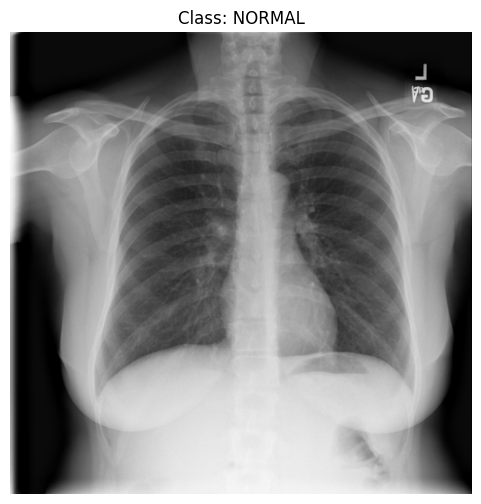

In [13]:
# ============================================================
# CELL 13 — DISPLAY ONE X-RAY
# ============================================================

sample_row = train_df.iloc[0]

image_path = sample_row["image_path"]
image_class = sample_row["class"]

image = Image.open(image_path)

print("Image path:")
print(image_path)

print("\nClass:")
print(image_class)

print("\nImage size:")
print(image.size)

plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")
plt.title(f"Class: {image_class}")
plt.axis("off")

plt.show()

In [14]:
# ============================================================
# CELL 14 — INSPECT IMAGE PROPERTIES
# ============================================================

print("Image mode:", image.mode)
print("Image width:", image.width)
print("Image height:", image.height)
print("Image format:", image.format)

Image mode: RGB
Image width: 512
Image height: 512
Image format: PNG


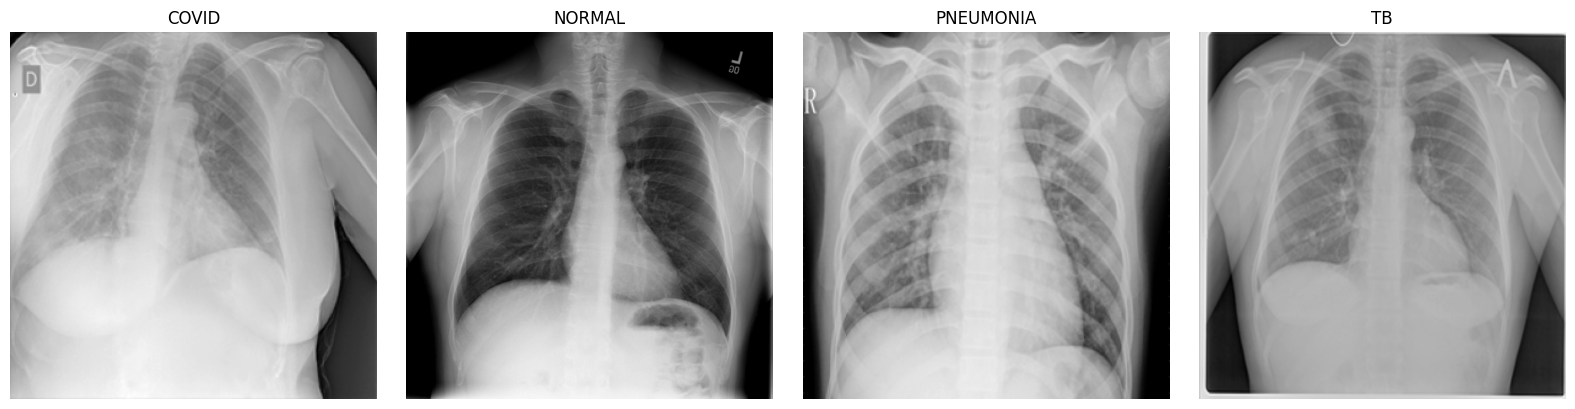

In [15]:
# ============================================================
# CELL 15 — ONE X-RAY FROM EACH CLASS
# ============================================================

classes = sorted(train_df["class"].unique())

fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(16, 4)
)

for ax, class_name in zip(axes, classes):

    class_data = train_df[
        train_df["class"] == class_name
    ]

    sample = class_data.sample(
        n=1,
        random_state=42
    ).iloc[0]

    img = Image.open(
        sample["image_path"]
    )

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(class_name)
    ax.axis("off")


plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CELL 16 — DEFINE CLASS LABELS
# ============================================================

CLASS_NAMES = [
    "COVID",
    "NORMAL",
    "PNEUMONIA",
    "TB"
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_INDEX.items()
}

print("Class to index:")
print(CLASS_TO_INDEX)

print("\nIndex to class:")
print(INDEX_TO_CLASS)

Class to index:
{'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TB': 3}

Index to class:
{0: 'COVID', 1: 'NORMAL', 2: 'PNEUMONIA', 3: 'TB'}


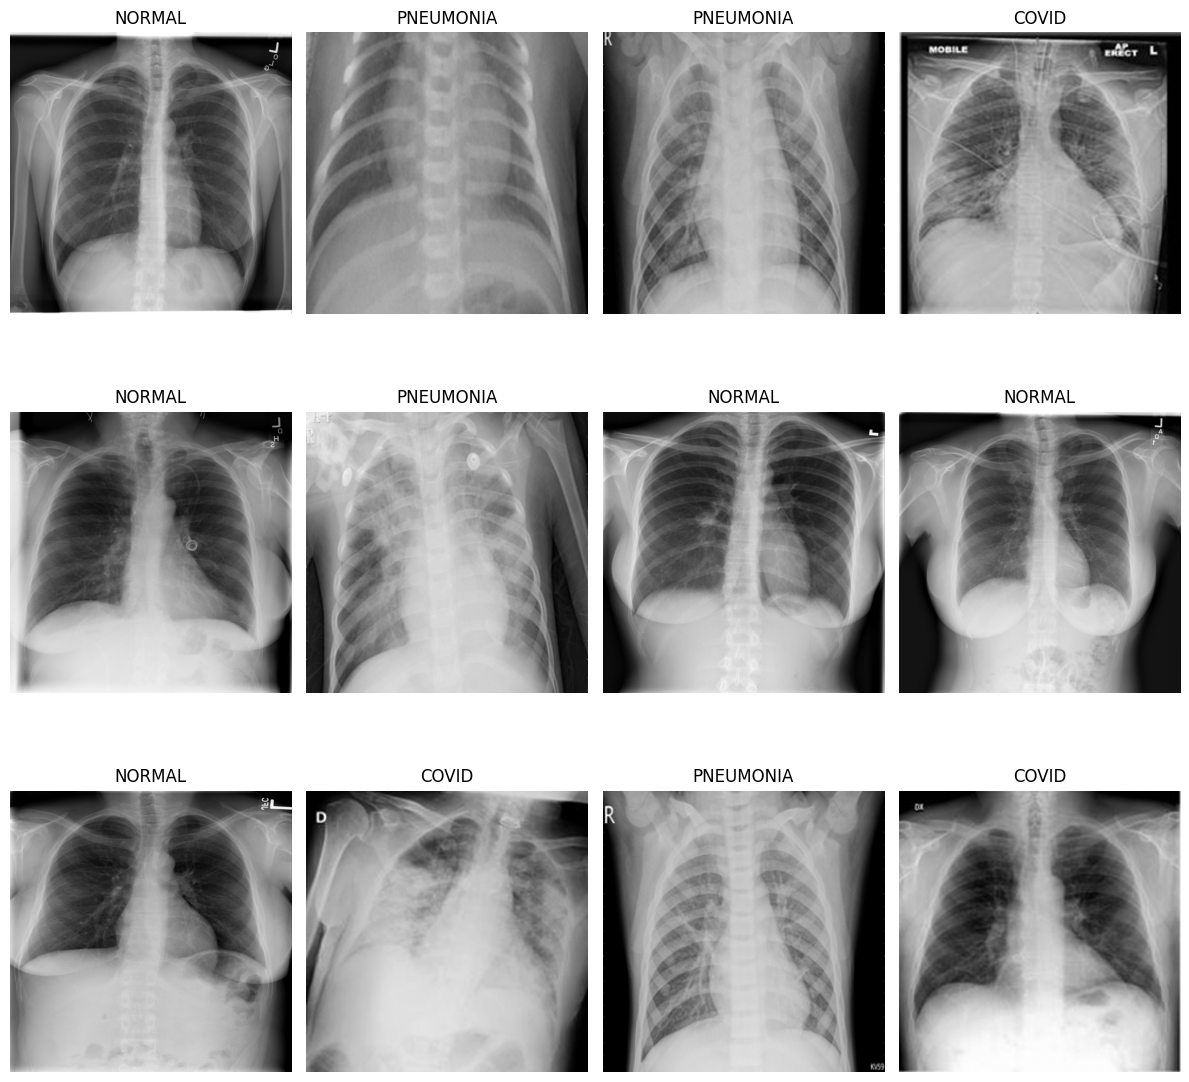

In [17]:
# ============================================================
# CELL 17 — RANDOM SAMPLE FROM THE DATASET
# ============================================================

NUM_SAMPLES = 12

samples = train_df.sample(
    n=NUM_SAMPLES,
    random_state=42
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 12)
)

for ax, (_, row) in zip(
    axes.ravel(),
    samples.iterrows()
):

    img = Image.open(
        row["image_path"]
    )

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(
        row["class"]
    )

    ax.axis("off")


plt.tight_layout()
plt.show()

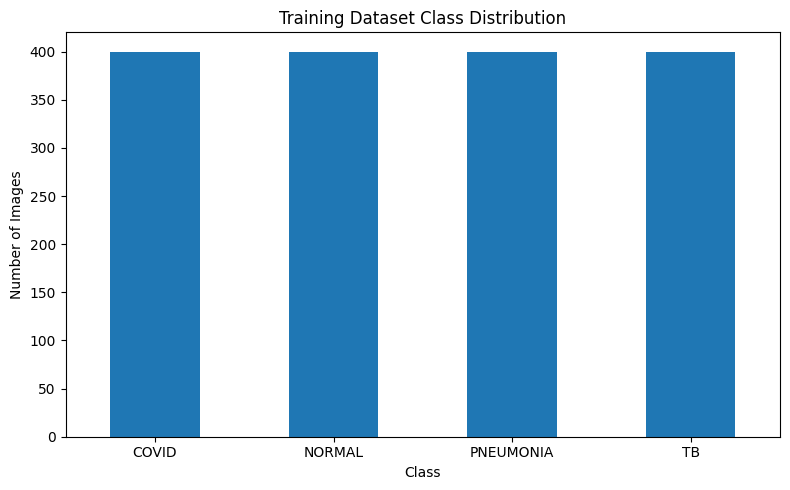

In [18]:
# ============================================================
# CELL 18 — CLASS DISTRIBUTION
# ============================================================

class_counts = train_df["class"].value_counts()

plt.figure(figsize=(8, 5))

class_counts.sort_index().plot(
    kind="bar"
)

plt.title(
    "Training Dataset Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 19 — INSTALL MEDSIGLIP REQUIREMENTS
# ============================================================
# NOTE: Do NOT upgrade torch here. Colab ships a torch + torchvision +
# CUDA stack that are version-matched to each other (and to RAPIDS
# libraries like cudf/cuml, if present). Force-upgrading torch breaks
# that match and produces the dependency-conflict warnings you'll see
# if you add --upgrade to the line below. transformers/accelerate are
# lightweight and safe to install on top of the existing torch.

!pip install -q transformers accelerate

import torch
print("torch version (unchanged from Colab default):", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


torch version (unchanged from Colab default): 2.11.0+cu128
CUDA available: True


In [20]:
# ============================================================
# CELL 20 — HUGGING FACE LOGIN
# ============================================================

from huggingface_hub import login

login()


In [21]:
# ============================================================
# CELL 21 — LOAD MEDSIGLIP MODEL AND PROCESSOR
# ============================================================
#
# NOTE: You must have accepted the Health AI Developer Foundations terms
# for MedSigLIP at https://huggingface.co/google/medsiglip-448 with the
# SAME Hugging Face account used to log in above, or this will fail with
# a "gated repo" error.

import torch
from transformers import AutoProcessor, AutoModel

MEDSIGLIP_MODEL_ID = "google/medsiglip-448"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

medsiglip_model = AutoModel.from_pretrained(MEDSIGLIP_MODEL_ID).to(device)
medsiglip_model.eval()

medsiglip_processor = AutoProcessor.from_pretrained(MEDSIGLIP_MODEL_ID)

print("MedSigLIP model and processor loaded successfully.")
print("Vision embedding dim:", medsiglip_model.config.vision_config.hidden_size)


Using device: cuda


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.51GB            

model.safetensors: downloading bytes:           |  0.00B            

...

spiece.model: reconstructing file:   0%|          |  0.00B /  798kB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/455 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

MedSigLIP model and processor loaded successfully.
Vision embedding dim: 1152


In [22]:
# ============================================================
# CELL 22 — HELPER: NORMALIZE get_image_features() OUTPUT
# ============================================================
# Depending on your installed transformers version, model.get_image_features()
# returns either a plain embedding tensor, or a ModelOutput object (e.g.
# BaseModelOutputWithPooling) that holds the embedding under .image_embeds
# or .pooler_output. This helper works with either version.

def get_image_embedding_tensor(model_output):
    if torch.is_tensor(model_output):
        return model_output
    if getattr(model_output, "image_embeds", None) is not None:
        return model_output.image_embeds
    if getattr(model_output, "pooler_output", None) is not None:
        return model_output.pooler_output
    # Last resort: assume the first element is the embedding tensor
    return model_output[0]

print("get_image_embedding_tensor() ready.")


get_image_embedding_tensor() ready.


In [23]:
# ============================================================
# CELL 23 — SANITY CHECK: EMBED ONE X-RAY
# ============================================================

sample_row = train_df.iloc[0]
sample_image = Image.open(sample_row["image_path"]).convert("RGB")

inputs = medsiglip_processor(images=sample_image, return_tensors="pt").to(device)

with torch.no_grad():
    raw_output = medsiglip_model.get_image_features(**inputs)

sample_embedding = get_image_embedding_tensor(raw_output).cpu().numpy()

print("Image class:", sample_row["class"])
print("Embedding shape:", sample_embedding.shape)
print("First 8 values:", sample_embedding[0, :8])


Image class: NORMAL
Embedding shape: (1, 1152)
First 8 values: [-0.17417912  0.16163838 -0.04623228 -0.09331092  0.01826222  0.13059735
  0.12471452 -0.14509669]


In [24]:
# ============================================================
# CELL 24 — BUILD TEST DATAFRAME
# ============================================================
# (train_df / val_df were already built earlier from TRAIN_FOLDER.
#  We still need an equivalent dataframe for TEST_FOLDER.)

test_records = []

for class_name in sorted(os.listdir(TEST_FOLDER)):

    class_path = os.path.join(TEST_FOLDER, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(IMAGE_EXTENSIONS):
            image_path = os.path.join(class_path, file_name)
            test_records.append({
                "image_path": image_path,
                "class": class_name
            })

test_df = pd.DataFrame(test_records)

print("Test dataframe created.")
print("Number of images:", len(test_df))
display(test_df.head())


Test dataframe created.
Number of images: 600


,image_path,class
0,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
1,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
2,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
3,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID
4,/content/drive/MyDrive/CXR_Foundation_Workshop...,COVID


In [25]:
# ============================================================
# CELL 25 — BATCH EMBEDDING EXTRACTION FUNCTION
# ============================================================

import numpy as np
from tqdm.auto import tqdm

BATCH_SIZE = 16  # lower this if you hit an out-of-memory error on a small GPU

def extract_medsiglip_embeddings(dataframe, batch_size=BATCH_SIZE):
    """
    Runs every image in dataframe['image_path'] through MedSigLIP and
    returns a (num_images, embedding_dim) numpy array of image embeddings,
    in the same row order as the input dataframe.
    """

    all_embeddings = []
    image_paths = dataframe["image_path"].tolist()

    for start in tqdm(range(0, len(image_paths), batch_size)):

        batch_paths = image_paths[start:start + batch_size]
        batch_images = [Image.open(p).convert("RGB") for p in batch_paths]

        inputs = medsiglip_processor(
            images=batch_images,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            raw_output = medsiglip_model.get_image_features(**inputs)

        batch_embeddings = get_image_embedding_tensor(raw_output)
        all_embeddings.append(batch_embeddings.cpu().numpy())

    return np.concatenate(all_embeddings, axis=0)

print("extract_medsiglip_embeddings() ready.")


extract_medsiglip_embeddings() ready.


In [26]:
# ============================================================
# CELL 26 — RUN EMBEDDING EXTRACTION FOR TRAIN / VAL / TEST
# ============================================================
# This is the slow cell — with a T4/L4 GPU, ~2,000 images takes a few
# minutes. On CPU it will be considerably slower; consider a smaller
# subset for a live demo if you're not on a GPU runtime.

print("Extracting TRAIN embeddings...")
X_train = extract_medsiglip_embeddings(train_df)

print("Extracting VALIDATION embeddings...")
X_val = extract_medsiglip_embeddings(val_df)

print("Extracting TEST embeddings...")
X_test = extract_medsiglip_embeddings(test_df)

y_train = train_df["class"].map(CLASS_TO_INDEX).to_numpy()
y_val = val_df["class"].map(CLASS_TO_INDEX).to_numpy()
y_test = test_df["class"].map(CLASS_TO_INDEX).to_numpy()

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)


Extracting TRAIN embeddings...


  0%|          | 0/100 [00:00<?, ?it/s]

Extracting VALIDATION embeddings...


  0%|          | 0/25 [00:00<?, ?it/s]

Extracting TEST embeddings...


  0%|          | 0/38 [00:00<?, ?it/s]


Shapes:
X_train: (1600, 1152) y_train: (1600,)
X_val:   (400, 1152) y_val:   (400,)
X_test:  (600, 1152) y_test:  (600,)


In [27]:
# ============================================================
# CELL 27 — SAVE EMBEDDINGS TO DRIVE
# ============================================================
# Saved so you never have to re-run the (slow) extraction step again —
# just reload from here if your runtime disconnects.

EMBEDDINGS_DIR = os.path.join(PROJECT_DIR, "embeddings")

np.savez(
    os.path.join(EMBEDDINGS_DIR, "medsiglip_embeddings.npz"),
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
)

print("Embeddings saved to:")
print(os.path.join(EMBEDDINGS_DIR, "medsiglip_embeddings.npz"))

# To reload later instead of re-running extraction:
# data = np.load(os.path.join(EMBEDDINGS_DIR, "medsiglip_embeddings.npz"))
# X_train, y_train = data["X_train"], data["y_train"]
# X_val, y_val     = data["X_val"], data["y_val"]
# X_test, y_test   = data["X_test"], data["y_test"]


Embeddings saved to:
/content/drive/MyDrive/CXR_Foundation_Workshop/embeddings/medsiglip_embeddings.npz


In [28]:
# ============================================================
# CELL 28 — BUILD A KERAS CLASSIFIER HEAD ON TOP OF THE EMBEDDINGS
# ============================================================
# MedSigLIP stays frozen — we only train this small head, which is
# exactly the "data-efficient classification" workflow the model card
# describes: cheap to train, since the heavy lifting already happened
# inside MedSigLIP.

from tensorflow import keras
from tensorflow.keras import layers

EMBEDDING_DIM = X_train.shape[1]
NUM_CLASSES = len(CLASS_NAMES)

classifier = keras.Sequential([
    layers.Input(shape=(EMBEDDING_DIM,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

classifier.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,876 (1.19 MB)

 Trainable params: 311,876 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ============================================================
# CELL 29 — TRAIN THE CLASSIFIER
# ============================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = classifier.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8644 - loss: 0.4133 - val_accuracy: 0.9900 - val_loss: 0.0756
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9669 - loss: 0.1097 - val_accuracy: 0.9900 - val_loss: 0.0427
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9856 - loss: 0.0527 - val_accuracy: 0.9900 - val_loss: 0.0273
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0421 - val_accuracy: 0.9950 - val_loss: 0.0211
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9919 - loss: 0.0321 - val_accuracy: 0.9875 - val_loss: 0.0257
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0235 - val_accuracy: 0.9950 - val_loss: 0.0181
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0163 - val_accuracy: 0.9950 - val_loss: 0.0165
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0182 - val_accuracy: 0.9925 - val_loss

In [30]:
# ============================================================
# CELL 30 — SET UP OUTPUT DIRECTORIES FOR PLOTS AND MODELS
# ============================================================
# The "plots" and "models" subfolders were already created back in
# CELL 4, alongside "dataset", "embeddings", "results", and "logs".
# Here we just point two Python variables at them so every plot and
# model file from this point onward has one, consistent home — and
# survives even if the Colab runtime disconnects, since PROJECT_DIR
# lives on your mounted Google Drive, not on the temporary VM disk.

PLOTS_DIR = os.path.join(PROJECT_DIR, "plots")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")

# exist_ok=True means this is safe to re-run without raising an error
# even though CELL 4 already created these folders once.
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Plots will be saved to:")
print(PLOTS_DIR)
print("\nModels will be saved to:")
print(MODELS_DIR)


Plots will be saved to:
/content/drive/MyDrive/CXR_Foundation_Workshop/plots

Models will be saved to:
/content/drive/MyDrive/CXR_Foundation_Workshop/models


Saved: /content/drive/MyDrive/CXR_Foundation_Workshop/plots/training_history.png


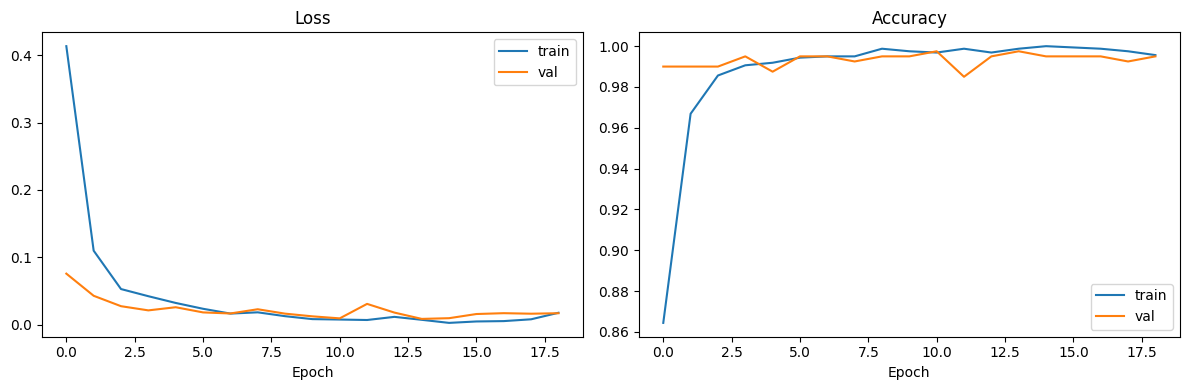

In [31]:
# ============================================================
# CELL 31 — PLOT TRAINING HISTORY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()

# Save the figure to the "plots" folder BEFORE plt.show() clears it
# from memory. dpi=150 keeps the file crisp without being huge, and
# bbox_inches="tight" trims excess whitespace around the figure.
plt.savefig(os.path.join(PLOTS_DIR, "training_history.png"), dpi=150, bbox_inches="tight")
print("Saved:", os.path.join(PLOTS_DIR, "training_history.png"))

plt.show()


Test accuracy: 0.9900
Test loss:     0.0530
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification report:
              precision    recall  f1-score   support

       COVID       0.99      0.98      0.98       150
      NORMAL       0.99      1.00      1.00       150
   PNEUMONIA       0.98      1.00      0.99       150
          TB       1.00      0.98      0.99       150

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

Saved: /content/drive/MyDrive/CXR_Foundation_Workshop/plots/confusion_matrix.png


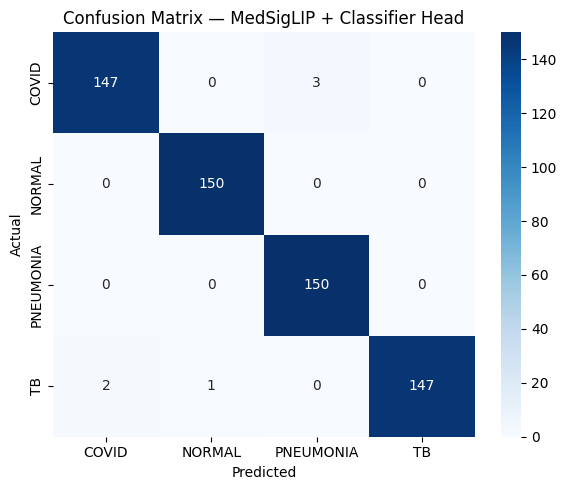

In [32]:
# ============================================================
# CELL 32 — EVALUATE ON THE TEST SET
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_accuracy = classifier.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss:     {test_loss:.4f}")

# y_prob holds the full probability distribution over all classes for
# every test image (shape: num_test_images x NUM_CLASSES). We keep
# this around because the ROC and Precision-Recall curve cells below
# need probabilities, not just the single most-likely class.
y_prob = classifier.predict(X_test)
y_pred = y_prob.argmax(axis=1)

print("\nClassification report:")
print(classification_report(
    y_test, y_pred, target_names=CLASS_NAMES
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MedSigLIP + Classifier Head")
plt.tight_layout()

# Save to the "plots" folder before displaying, same pattern as CELL 31.
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
print("Saved:", os.path.join(PLOTS_DIR, "confusion_matrix.png"))

plt.show()


Saved: /content/drive/MyDrive/CXR_Foundation_Workshop/plots/roc_curve.png


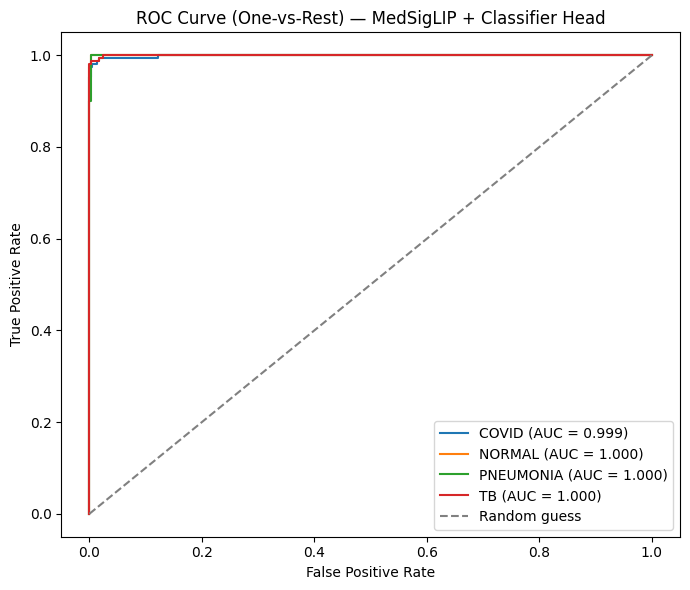

In [33]:
# ============================================================
# CELL 33 — GENERATE AND SAVE THE ROC CURVE
# ============================================================
# A ROC curve is normally defined for a single yes/no decision, but we
# have four classes (COVID, NORMAL, PNEUMONIA, TB). The standard way to
# handle this is "one-vs-rest": for each class in turn, we treat it as
# the "positive" class and every other class as "negative", then draw
# one ROC curve per class on the same axes so they're easy to compare.

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# label_binarize turns y_test (a list of class indices like [0, 2, 1, ...])
# into a "one-hot" style matrix, e.g. class 2 out of 4 becomes [0,0,1,0].
# This is the format one-vs-rest ROC/PR calculations expect.
y_test_binarized = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(7, 6))

for class_index, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_index], y_prob[:, class_index])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

# The diagonal dashed line represents "random guessing" — a useful
# reference so you can see at a glance how much better than chance
# each class's curve performs.
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest) — MedSigLIP + Classifier Head")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "roc_curve.png"), dpi=150, bbox_inches="tight")
print("Saved:", os.path.join(PLOTS_DIR, "roc_curve.png"))

plt.show()


Saved: /content/drive/MyDrive/CXR_Foundation_Workshop/plots/precision_recall_curve.png


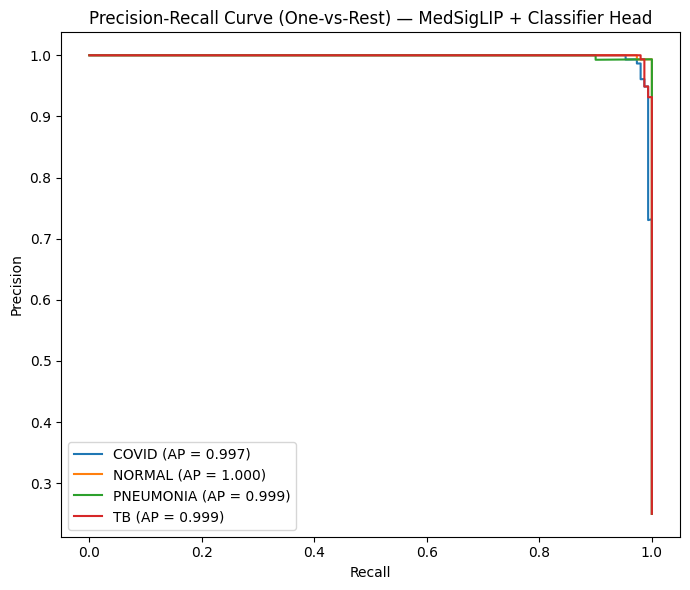

In [34]:
# ============================================================
# CELL 34 — GENERATE AND SAVE THE PRECISION-RECALL CURVE
# ============================================================
# Precision-Recall curves are especially useful for medical imaging
# tasks like this one, where classes can be imbalanced (e.g. far more
# NORMAL images than TB images). ROC curves can look overly optimistic
# under class imbalance, so it's good practice to check both.
# Same one-vs-rest approach as the ROC curve above.

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))

for class_index, class_name in enumerate(CLASS_NAMES):
    precision, recall, _ = precision_recall_curve(
        y_test_binarized[:, class_index], y_prob[:, class_index]
    )
    avg_precision = average_precision_score(
        y_test_binarized[:, class_index], y_prob[:, class_index]
    )
    plt.plot(recall, precision, label=f"{class_name} (AP = {avg_precision:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (One-vs-Rest) — MedSigLIP + Classifier Head")
plt.legend(loc="lower left")
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "precision_recall_curve.png"), dpi=150, bbox_inches="tight")
print("Saved:", os.path.join(PLOTS_DIR, "precision_recall_curve.png"))

plt.show()


Saved: /content/drive/MyDrive/CXR_Foundation_Workshop/plots/tsne_embeddings.png


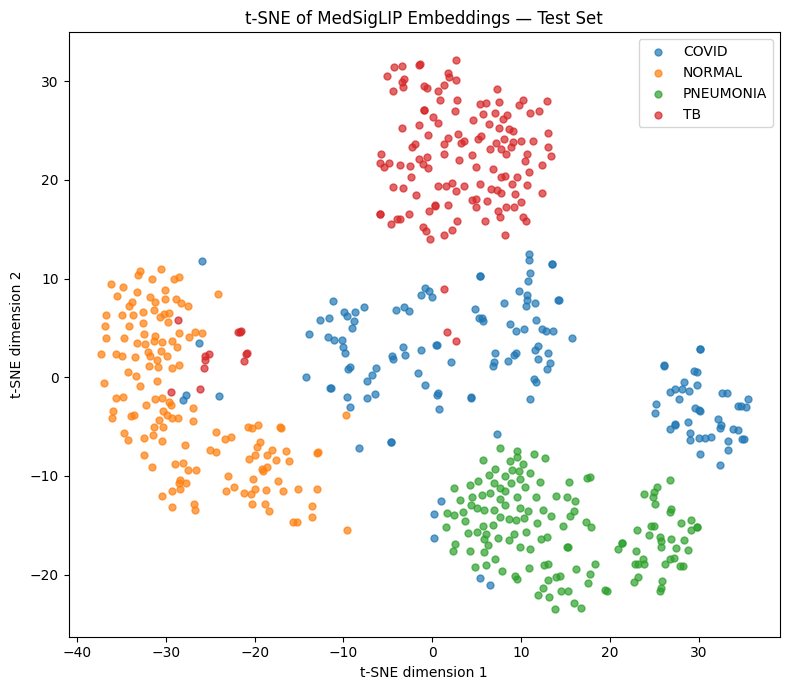

In [35]:
# ============================================================
# CELL 35 — VISUALIZE TEST EMBEDDINGS WITH T-SNE
# ============================================================
# Our MedSigLIP embeddings are 1152-dimensional — far too many
# dimensions to plot directly. t-SNE compresses each embedding down
# to just 2 dimensions while trying to preserve which points were
# close together in the original high-dimensional space. If MedSigLIP
# is producing genuinely useful embeddings, images from the same class
# should form visible clusters here, BEFORE our classifier head even
# gets involved — a nice sanity check on the embeddings themselves.

from sklearn.manifold import TSNE

# perplexity roughly controls how many neighbors t-SNE considers per
# point, and must be smaller than the number of samples. We cap it at
# 30 (a common default) but shrink it automatically for small test
# sets so this cell doesn't crash on a small workshop dataset.
tsne_perplexity = min(30, len(X_test) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    init="pca",
    random_state=42,
)
embeddings_2d = tsne.fit_transform(X_test)

plt.figure(figsize=(8, 7))

for class_index, class_name in enumerate(CLASS_NAMES):
    mask = y_test == class_index
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=class_name,
        alpha=0.7,
        s=25,
    )

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("t-SNE of MedSigLIP Embeddings — Test Set")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(PLOTS_DIR, "tsne_embeddings.png"), dpi=150, bbox_inches="tight")
print("Saved:", os.path.join(PLOTS_DIR, "tsne_embeddings.png"))

plt.show()


In [36]:
# ============================================================
# CELL 36 — GRAD-CAM-STYLE EXPLAINABILITY FOR ONE X-RAY
# ============================================================
# Grad-CAM answers the question: "which parts of this image mattered
# most for the model's prediction?" It normally requires a single
# model with everything connected end-to-end. Our pipeline is a bit
# different — MedSigLIP (PyTorch) extracts a frozen embedding, and a
# SEPARATE Keras/TensorFlow classifier turns that embedding into a
# class prediction. Gradients can't flow directly between two
# different frameworks, so we bridge them in two steps:
#
#   Step 1 (TensorFlow): find out which embedding dimensions the
#           classifier cares about most for its predicted class.
#   Step 2 (PyTorch): trace THOSE embedding dimensions back to the
#           image patches inside MedSigLIP that produced them.
#
# The result is a heatmap over the original X-ray, exactly like a
# standard Grad-CAM, just computed across two frameworks instead of one.

import numpy as np
import tensorflow as tf
import torch.nn.functional as F

# ---- Pick one test image to explain ----
example_row = test_df.iloc[0]
example_image = Image.open(example_row["image_path"]).convert("RGB")

# ---- Step 1: TensorFlow — gradient of the predicted class score
#              with respect to the embedding vector ----
example_inputs = medsiglip_processor(images=example_image, return_tensors="pt").to(device)

with torch.no_grad():
    example_raw_output = medsiglip_model.get_image_features(**example_inputs)
example_embedding = get_image_embedding_tensor(example_raw_output).cpu().numpy()

embedding_tf = tf.convert_to_tensor(example_embedding)
with tf.GradientTape() as tape:
    tape.watch(embedding_tf)
    class_probs = classifier(embedding_tf)
    predicted_class_index = int(tf.argmax(class_probs[0]))
    predicted_class_score = class_probs[0, predicted_class_index]

# embedding_sensitivity tells us, for each of the 1152 embedding
# dimensions, how much increasing it would increase the predicted
# class's score. This becomes our "target direction" for Step 2.
embedding_sensitivity = tape.gradient(predicted_class_score, embedding_tf).numpy()

print(f"Predicted class: {CLASS_NAMES[predicted_class_index]} "
      f"({float(predicted_class_score):.3f} confidence)")
print(f"True class: {example_row['class']}")

# ---- Step 2: PyTorch — backpropagate that target direction through
#              the frozen MedSigLIP vision encoder, down to the
#              patch-level tokens (i.e. before they get pooled into
#              a single embedding vector) ----
pixel_values = example_inputs["pixel_values"].clone().requires_grad_(True)

# medsiglip_model.vision_model is the underlying vision transformer.
# Calling it directly (instead of get_image_features) gives us access
# to last_hidden_state: one vector per image patch, before pooling.
# This matches the "pooler_output" branch of the get_image_embedding_tensor
# helper from CELL 22 — i.e. this pooled_embedding should closely match
# the embedding we extracted in Step 1 above.
vision_outputs = medsiglip_model.vision_model(pixel_values=pixel_values)
patch_tokens = vision_outputs.last_hidden_state      # [1, num_patches, hidden_dim]
pooled_embedding = vision_outputs.pooler_output       # [1, hidden_dim]

sensitivity_torch = torch.tensor(
    embedding_sensitivity, dtype=pooled_embedding.dtype, device=device
)

# This dot product is a single number summarizing "how much does this
# specific image, in the direction the classifier cares about, matter?"
# Backpropagating it gives us a gradient on every patch token.
directional_score = torch.sum(pooled_embedding * sensitivity_torch)
medsiglip_model.zero_grad()
directional_score.backward()

patch_gradients = patch_tokens.grad[0]     # [num_patches, hidden_dim]
patch_activations = patch_tokens[0].detach()

# Standard Grad-CAM weighting: multiply each patch's activation by its
# gradient, sum over the hidden dimension, then discard negative values
# (ReLU) since we only care about evidence FOR the predicted class.
cam_weights = (patch_gradients * patch_activations).sum(dim=-1)
cam_weights = F.relu(cam_weights).cpu().numpy()

# ---- Reshape the flat list of patch scores back into a 2D grid ----
num_patches = cam_weights.shape[0]
grid_size = int(round(num_patches ** 0.5))

if grid_size * grid_size == num_patches:
    cam_grid = cam_weights.reshape(grid_size, grid_size)

    # Normalize to 0-1 so it displays as a clean heatmap.
    if cam_grid.max() > 0:
        cam_grid = cam_grid / cam_grid.max()

    # Upsample the small patch grid back to the original image size
    # so we can overlay it directly on the X-ray.
    cam_image = Image.fromarray(np.uint8(cam_grid * 255)).resize(
        example_image.size, resample=Image.BICUBIC
    )
    cam_resized = np.array(cam_image) / 255.0

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    axes[0].imshow(example_image)
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")

    axes[1].imshow(example_image)
    axes[1].imshow(cam_resized, cmap="jet", alpha=0.45)
    axes[1].set_title(f"Grad-CAM — predicted: {CLASS_NAMES[predicted_class_index]}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "gradcam_example.png"), dpi=150, bbox_inches="tight")
    print("Saved:", os.path.join(PLOTS_DIR, "gradcam_example.png"))
    plt.show()
else:
    # This should be rare, but if MedSigLIP's patch count isn't a
    # perfect square (depends on model/version), we can't reshape it
    # into a square grid — flag it clearly rather than silently failing.
    print(f"Could not reshape {num_patches} patches into a square grid — "
          f"skipping the heatmap overlay for this model version.")


Predicted class: COVID (1.000 confidence)
True class: COVID


/tmp/ipykernel_1444/722881827.py:79: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  patch_gradients = patch_tokens.grad[0]     # [num_patches, hidden_dim]


TypeError: 'NoneType' object is not subscriptable

In [37]:
# ============================================================
# CELL 37 — SAVE THE TRAINED CLASSIFIER MODEL
# ============================================================
# This saves the small Keras classifier head we trained on top of the
# frozen MedSigLIP embeddings — NOT MedSigLIP itself (that stays as
# the pretrained model downloaded from Hugging Face; we never modified
# its weights). The ".keras" format is the current standard Keras save
# format and stores the architecture, weights, and optimizer state
# together in a single file.

keras_model_path = os.path.join(MODELS_DIR, "cxr_classifier.keras")
classifier.save(keras_model_path)

print("Saved trained classifier to:")
print(keras_model_path)

# To reload later:
# from tensorflow import keras
# classifier = keras.models.load_model(keras_model_path)


Saved trained classifier to:
/content/drive/MyDrive/CXR_Foundation_Workshop/models/cxr_classifier.keras


In [38]:
# ============================================================
# CELL 38 — CONVERT THE CLASSIFIER TO TFLITE
# ============================================================
# TFLite (TensorFlow Lite) is a lightweight model format built for
# running on phones, edge devices, and other low-resource hardware —
# exactly the kind of setting where offline, low-connectivity clinics
# would need to run this classifier. This first conversion keeps the
# model's original float32 precision (no quantization yet).

converter = tf.lite.TFLiteConverter.from_keras_model(classifier)
tflite_model = converter.convert()

tflite_path = os.path.join(MODELS_DIR, "cxr_classifier.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

original_size_kb = os.path.getsize(keras_model_path) / 1024
tflite_size_kb = os.path.getsize(tflite_path) / 1024

print("Saved TFLite model to:")
print(tflite_path)
print(f"\nKeras model size: {original_size_kb:.1f} KB")
print(f"TFLite model size: {tflite_size_kb:.1f} KB")


Saved artifact at '/tmp/tmp6deszv2v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1152), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139524131843792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131839760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131845520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131842448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131839568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131841680: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved TFLite model to:
/content/drive/MyDrive/CXR_Foundation_Workshop/models/cxr_classifier.tflite

Keras model size: 3684.0 KB
TFLite model size: 1220.3 KB


In [39]:
# ============================================================
# CELL 39 — CREATE A QUANTIZED TFLITE MODEL
# ============================================================
# Quantization shrinks the model further by storing its weights with
# fewer bits of precision (roughly: converting decimal numbers to
# "good enough" approximations). This is the single biggest lever for
# making a model small and fast enough for edge deployment, usually
# with only a very small accuracy trade-off for a classifier this
# simple. We use "dynamic range" quantization here — it needs no
# extra calibration data, which keeps this workshop step simple. Full
# integer quantization (an even smaller model) is possible but needs
# a representative sample dataset — a good extension exercise, not
# required here.

converter_quant = tf.lite.TFLiteConverter.from_keras_model(classifier)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter_quant.convert()

tflite_quant_path = os.path.join(MODELS_DIR, "cxr_classifier_quant.tflite")
with open(tflite_quant_path, "wb") as f:
    f.write(tflite_quant_model)

quant_size_kb = os.path.getsize(tflite_quant_path) / 1024
size_reduction_pct = 100 * (1 - quant_size_kb / tflite_size_kb)

print("Saved quantized TFLite model to:")
print(tflite_quant_path)
print(f"\nFloat32 TFLite size:  {tflite_size_kb:.1f} KB")
print(f"Quantized TFLite size: {quant_size_kb:.1f} KB")
print(f"Size reduction: {size_reduction_pct:.1f}%")

# ---- Quick sanity check: does quantization hurt accuracy much? ----
# We run the quantized model on the whole test set and compare its
# accuracy to the original Keras classifier's test accuracy from CELL 32.
interpreter_check = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter_check.allocate_tensors()
input_details = interpreter_check.get_input_details()
output_details = interpreter_check.get_output_details()

quant_predictions = []
for embedding_vector in X_test:
    interpreter_check.set_tensor(
        input_details[0]["index"], embedding_vector[None, :].astype(np.float32)
    )
    interpreter_check.invoke()
    output = interpreter_check.get_tensor(output_details[0]["index"])
    quant_predictions.append(int(output.argmax()))

quant_accuracy = float(np.mean(np.array(quant_predictions) == y_test))
print(f"\nOriginal classifier test accuracy:  {test_accuracy:.4f}")
print(f"Quantized TFLite test accuracy:     {quant_accuracy:.4f}")


Saved artifact at '/tmp/tmpjgg9nvfv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1152), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139524131843792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131839760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131845520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131842448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131839568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139524131841680: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved quantized TFLite model to:
/content/drive/MyDrive/CXR_Foundation_Workshop/models/cxr_classifier_quant.tflite

Float32 TFLite size:  1220.3 KB
Quantized TFLite size: 312.1 KB
Size reduction: 74.4%

Original classifier test accuracy:  0.9900
Quantized TFLite test accuracy:     0.9900


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [40]:
# ============================================================
# CELL 40 — BUILD AND SAVE AN END-TO-END INFERENCE PIPELINE
# ============================================================
# Everything so far has produced individual pieces: an embedding
# extractor, a trained classifier, a quantized TFLite file. This cell
# packages them into one reusable "inference model" — a single
# function that takes a raw chest X-ray file path and returns a
# diagnosis, using the quantized TFLite model for the classification
# step. This is the artifact you'd actually hand off for deployment.

import json

# Reuse the same quantized interpreter from CELL 39 rather than
# reloading it from disk, to keep this demo fast.
inference_interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
inference_interpreter.allocate_tensors()
inference_input_details = inference_interpreter.get_input_details()
inference_output_details = inference_interpreter.get_output_details()


def run_inference_pipeline(image_path):
    """
    End-to-end inference: raw X-ray image path -> predicted class.

    This mirrors, step for step, the pipeline diagram from earlier in
    the workshop: image -> MedSigLIP embedding (frozen) -> quantized
    classifier -> predicted class + confidence.
    """
    image = Image.open(image_path).convert("RGB")

    # Step 1: MedSigLIP embedding (same call as CELL 25's batch version,
    # just for a single image here).
    inputs = medsiglip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        raw_output = medsiglip_model.get_image_features(**inputs)
    embedding = get_image_embedding_tensor(raw_output).cpu().numpy().astype(np.float32)

    # Step 2: quantized TFLite classifier.
    inference_interpreter.set_tensor(inference_input_details[0]["index"], embedding)
    inference_interpreter.invoke()
    probabilities = inference_interpreter.get_tensor(inference_output_details[0]["index"])[0]

    predicted_index = int(probabilities.argmax())
    return {
        "predicted_class": CLASS_NAMES[predicted_index],
        "confidence": float(probabilities[predicted_index]),
        "all_class_probabilities": {
            CLASS_NAMES[i]: float(p) for i, p in enumerate(probabilities)
        },
    }


# ---- Save the metadata a deployment would need alongside the .tflite
#      file — class names and the model this pipeline expects, so
#      someone picking this up later doesn't have to guess. ----
inference_metadata = {
    "embedding_model": MEDSIGLIP_MODEL_ID,
    "classifier_file": "cxr_classifier_quant.tflite",
    "class_names": CLASS_NAMES,
    "embedding_dim": int(EMBEDDING_DIM),
}
metadata_path = os.path.join(MODELS_DIR, "inference_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(inference_metadata, f, indent=2)

print("Saved inference metadata to:")
print(metadata_path)

# ---- Demo: run the full pipeline on one test image ----
demo_row = test_df.iloc[0]
result = run_inference_pipeline(demo_row["image_path"])

print("\n--- Demo prediction ---")
print("Image:", demo_row["image_path"])
print("True class:", demo_row["class"])
print("Predicted class:", result["predicted_class"], f"({result['confidence']:.3f} confidence)")
print("All class probabilities:", result["all_class_probabilities"])


Saved inference metadata to:
/content/drive/MyDrive/CXR_Foundation_Workshop/models/inference_metadata.json

--- Demo prediction ---
Image: /content/drive/MyDrive/CXR_Foundation_Workshop/dataset/raw/my_dataset/test_folder/COVID/COVID-510.png
True class: COVID
Predicted class: COVID (1.000 confidence)
All class probabilities: {'COVID': 0.9999990463256836, 'NORMAL': 5.2701686570344464e-08, 'PNEUMONIA': 5.772742497356376e-07, 'TB': 3.232190124435874e-07}
